In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import os

In [47]:
import sys
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *

In [48]:
path_data = os.path.join(FEATURE_ORIGINAL_DATA, 'features_40.csv')
path_save = os.path.join(MODEL, "group_samples")
os.makedirs(path_save, exist_ok=True)

In [49]:
with open(os.path.join(CONFIG, "feature.yaml"), "r") as f:
    feature_config = yaml.safe_load(f)

print(feature_config)

{'7DT_20': {'color': ['m400-m425', 'm400-m450', 'm400-m475', 'm400-m500', 'm400-m525', 'm400-m550', 'm400-m575', 'm400-m600', 'm400-m625', 'm400-m650', 'm400-m675', 'm400-m700', 'm400-m725', 'm400-m750', 'm400-m775', 'm400-m800', 'm400-m825', 'm400-m850', 'm400-m875', 'm425-m450', 'm425-m475', 'm425-m500', 'm425-m525', 'm425-m550', 'm425-m575', 'm425-m600', 'm425-m625', 'm425-m650', 'm425-m675', 'm425-m700', 'm425-m725', 'm425-m750', 'm425-m775', 'm425-m800', 'm425-m825', 'm425-m850', 'm425-m875', 'm450-m475', 'm450-m500', 'm450-m525', 'm450-m550', 'm450-m575', 'm450-m600', 'm450-m625', 'm450-m650', 'm450-m675', 'm450-m700', 'm450-m725', 'm450-m750', 'm450-m775', 'm450-m800', 'm450-m825', 'm450-m850', 'm450-m875', 'm475-m500', 'm475-m525', 'm475-m550', 'm475-m575', 'm475-m600', 'm475-m625', 'm475-m650', 'm475-m675', 'm475-m700', 'm475-m725', 'm475-m750', 'm475-m775', 'm475-m800', 'm475-m825', 'm475-m850', 'm475-m875', 'm500-m525', 'm500-m550', 'm500-m575', 'm500-m600', 'm500-m625', 'm5

In [61]:
feature_type_config = feature_config['7DT_40']

print(feature_type_config)
print(feature_type_config.keys())

{'color': ['m400-m412', 'm400-m425', 'm400-m437', 'm400-m450', 'm400-m462', 'm400-m475', 'm400-m487', 'm400-m500', 'm400-m512', 'm400-m525', 'm400-m537', 'm400-m550', 'm400-m562', 'm400-m575', 'm400-m587', 'm400-m600', 'm400-m612', 'm400-m625', 'm400-m637', 'm400-m650', 'm400-m662', 'm400-m675', 'm400-m687', 'm400-m700', 'm400-m712', 'm400-m725', 'm400-m737', 'm400-m750', 'm400-m762', 'm400-m775', 'm400-m787', 'm400-m800', 'm400-m812', 'm400-m825', 'm400-m837', 'm400-m850', 'm400-m862', 'm400-m875', 'm400-m887', 'm412-m425', 'm412-m437', 'm412-m450', 'm412-m462', 'm412-m475', 'm412-m487', 'm412-m500', 'm412-m512', 'm412-m525', 'm412-m537', 'm412-m550', 'm412-m562', 'm412-m575', 'm412-m587', 'm412-m600', 'm412-m612', 'm412-m625', 'm412-m637', 'm412-m650', 'm412-m662', 'm412-m675', 'm412-m687', 'm412-m700', 'm412-m712', 'm412-m725', 'm412-m737', 'm412-m750', 'm412-m762', 'm412-m775', 'm412-m787', 'm412-m800', 'm412-m812', 'm412-m825', 'm412-m837', 'm412-m850', 'm412-m862', 'm412-m875', '

1. color-only
2. residual-only
3. semi-global color-only
4. color+residual
5. color+semi-global
6. color+residual+semi-global

In [162]:
feature_combination_name = "color"
feature_combination_name = "residual"
feature_combination_name = "semi_global_color"
feature_combination_name = "color+residual"
feature_combination_name = "color+semi_global_color"
feature_combination_name = "color+residual+semi_global_color"


feature_combination_dict = {
	"color": feature_type_config['color'],
	"residual": feature_type_config['res1'],
	"semi_global_color": feature_type_config['semi_global_color'],
	"color+residual": feature_type_config['color'] + feature_type_config['res1'],
	"color+semi_global_color": feature_type_config['color'] + feature_type_config['semi_global_color'],
	"color+residual+semi_global_color": feature_type_config['color'] + feature_type_config['res1'] + feature_type_config['semi_global_color'],
}

features_to_consider = feature_combination_dict[feature_combination_name]

print(features_to_consider)

['m400-m412', 'm400-m425', 'm400-m437', 'm400-m450', 'm400-m462', 'm400-m475', 'm400-m487', 'm400-m500', 'm400-m512', 'm400-m525', 'm400-m537', 'm400-m550', 'm400-m562', 'm400-m575', 'm400-m587', 'm400-m600', 'm400-m612', 'm400-m625', 'm400-m637', 'm400-m650', 'm400-m662', 'm400-m675', 'm400-m687', 'm400-m700', 'm400-m712', 'm400-m725', 'm400-m737', 'm400-m750', 'm400-m762', 'm400-m775', 'm400-m787', 'm400-m800', 'm400-m812', 'm400-m825', 'm400-m837', 'm400-m850', 'm400-m862', 'm400-m875', 'm400-m887', 'm412-m425', 'm412-m437', 'm412-m450', 'm412-m462', 'm412-m475', 'm412-m487', 'm412-m500', 'm412-m512', 'm412-m525', 'm412-m537', 'm412-m550', 'm412-m562', 'm412-m575', 'm412-m587', 'm412-m600', 'm412-m612', 'm412-m625', 'm412-m637', 'm412-m650', 'm412-m662', 'm412-m675', 'm412-m687', 'm412-m700', 'm412-m712', 'm412-m725', 'm412-m737', 'm412-m750', 'm412-m762', 'm412-m775', 'm412-m787', 'm412-m800', 'm412-m812', 'm412-m825', 'm412-m837', 'm412-m850', 'm412-m862', 'm412-m875', 'm412-m887'

In [163]:
# 1. Load and Concatenate Data
data = pd.read_csv(path_data)

In [164]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV"
]
indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)
print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")

9 sources to consider: 5778


In [165]:
subdata = data.iloc[indx_type_to_consider]

# Class 컬럼 추출
labels = subdata['Class']

# feature만 추출 (Sample_ID, Class 제외)
features = subdata.drop(['Sample_ID', 'Class', 'uid'], axis=1)[features_to_consider]
features

,m400-m412,m400-m425,m400-m437,m400-m450,m400-m462,m400-m475,m400-m487,m400-m500,m400-m512,m400-m525,...,c10_m525_637-c10_m775_887,c10_m587_700-c10_m650_762,c10_m587_700-c10_m712_825,c10_m587_700-c10_m775_887,c10_m650_762-c10_m712_825,c10_m650_762-c10_m775_887,c10_m712_825-c10_m775_887,c20_m400_637-c20_m525_762,c20_m400_637-c20_m650_887,c20_m525_762-c20_m650_887
0,0.315,0.289,0.033,0.059,0.300,0.300,0.135,-0.013,0.088,0.287,...,-0.2241,-0.0344,-0.2210,-0.2887,-0.1866,-0.2543,-0.0677,0.03565,-0.07640,-0.11205
1,0.322,0.453,0.394,0.283,0.411,0.653,0.599,0.399,0.313,0.428,...,-0.7829,-0.2811,-0.5962,-0.6887,-0.3151,-0.4076,-0.0925,-0.08440,-0.47585,-0.39145
2,0.297,0.369,0.152,0.009,0.273,0.354,0.190,0.089,0.098,0.281,...,-0.3472,-0.1966,-0.3813,-0.3367,-0.1847,-0.1401,0.0446,-0.02400,-0.19760,-0.17360
3,0.325,0.334,0.125,0.020,0.198,0.244,0.132,0.009,0.024,0.158,...,-0.6634,-0.2480,-0.5259,-0.5883,-0.2779,-0.3403,-0.0624,-0.19855,-0.53025,-0.33170
4,0.223,0.408,0.360,0.217,0.309,0.506,0.451,0.296,0.277,0.377,...,-0.1327,-0.1274,-0.2395,-0.2090,-0.1121,-0.0816,0.0305,0.06310,-0.00325,-0.06635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6054,0.067,0.179,0.276,0.326,0.411,0.558,0.659,0.678,0.744,0.727,...,0.4800,0.0981,0.1724,0.3058,0.0743,0.2077,0.1334,0.36105,0.60105,0.24000
6055,0.134,0.054,0.180,0.240,0.145,0.078,0.114,0.315,0.345,0.276,...,0.2733,0.0846,0.1383,0.2649,0.0537,0.1803,0.1266,0.00955,0.14620,0.13665
6056,-0.151,-0.102,-0.149,-0.067,-0.024,-0.019,0.043,0.093,0.141,0.215,...,0.5174,0.1237,0.2113,0.3461,0.0876,0.2224,0.1348,0.33880,0.59750,0.25870
6057,-0.005,-0.054,-0.019,-0.050,-0.043,-0.008,0.055,0.087,0.064,0.052,...,0.0044,0.0282,-0.0222,0.0132,-0.0504,-0.0150,0.0354,-0.05880,-0.05660,0.00220


In [166]:
# --- PCA 2D ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(features)

In [167]:
# --- UMAP 2D ---
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(features)

In [168]:
# --- 시각화 함수 ---
def plot_2d_embedding(X, labels, title):
    plt.figure(figsize=(8, 6))
    unique_labels = sorted(labels.unique())
    for c in unique_labels:
        idx = labels == c
        plt.scatter(X[idx, 0], X[idx, 1], label=str(c), alpha=0.5, s=15)
    plt.legend()
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, ls='--', alpha=0.3)
    plt.tight_layout()
    # plt.show()

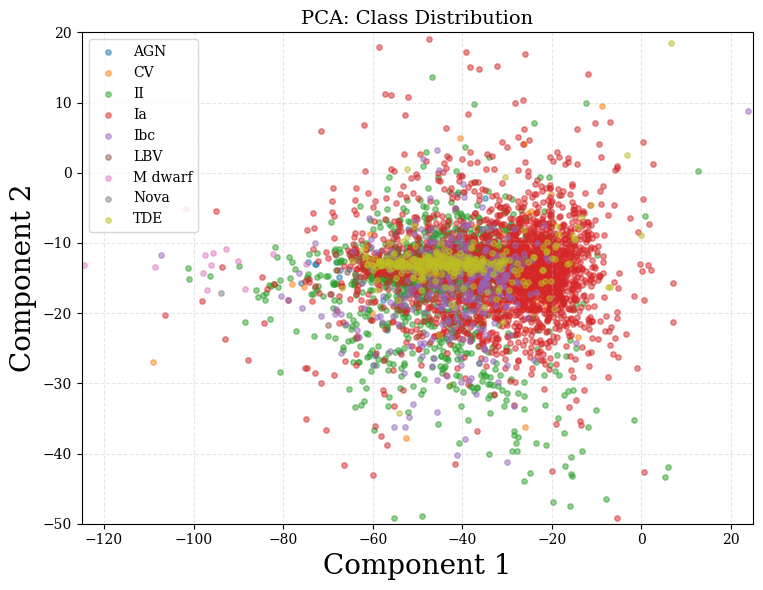

In [169]:
plot_2d_embedding(X_pca, labels, 'PCA: Class Distribution')
plt.xlim(-125, 25)
plt.ylim(-50, 20)
plt.show()

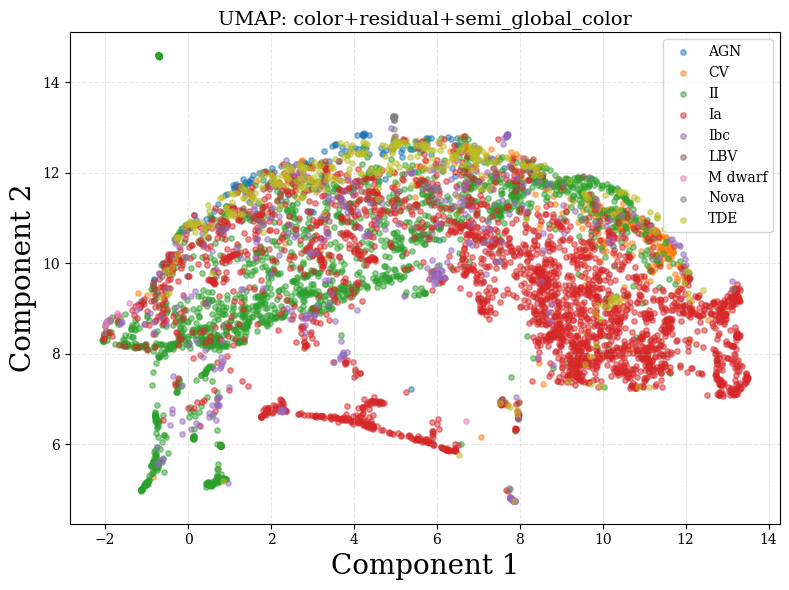

In [ ]:
plot_2d_embedding(X_umap, labels, f'UMAP: {feature_combination_name}')
plt.savefig(os.path.join(path_save, f'umap_{feature_combination_name}.png'))